In [1]:
import os, sys
sys.path.append('..')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.evaluate import get_edges_sensitivity
resdir = os.path.join('..', 'DELAY', 'recalls-spillover-data')
datadir = os.path.join('..', 'stock-market-dataset')
fn_events = os.path.join(datadir, 'health_stocks_events.csv')
events = pd.read_csv(fn_events, index_col = 0, parse_dates = True).abs()
window = pd.Timedelta(days = 7)

## Ground truth network sensitivity

In [2]:
edges_ref = pd.read_csv(os.path.join(resdir, 'refNetwork.csv'))
edges_ref['value'] = 1; ix = edges_ref.Gene2.sort_values().unique()
edges_ref = (edges_ref
             .pivot_table(index = 'Gene1', columns = 'Gene2', values = 'value', fill_value = 0)
             .reindex(index = ix, columns = ix, fill_value = 0)
             .pipe(get_edges_sensitivity, events = events, window = window)
             .stack().rename('recall').reset_index()
             .pipe(pd.merge, right = edges_ref, on = ['Gene1', 'Gene2'])
             .pipe(lambda df: df.loc[df.Gene1 != df.Gene2, ['Gene1', 'Gene2', 'recall']])
             .sort_values('recall', ascending = False))
edges_ref

,Gene1,Gene2,recall
62,BDX,SCNI,0.664667
117,CAH,PRGO,0.598403
51,BAX,WST,0.398605
17,BAX,FONR,0.397404
36,BAX,SCLX,0.394584
...,...,...,...
155,ICUI,ACHV,-0.011733
229,ICUI,TOVX,-0.012072
99,CAH,CASI,-0.013092
182,ICUI,GCTK,-0.013772


## DELAY network sensitivity

In [3]:
A_pred = pd.read_csv(os.path.join(resdir, 'networkTop1000.csv'), index_col = 0)
A_pred.index = A_pred.index.str.upper(); A_pred.columns = A_pred.columns.str.upper()
A_pred.rename_axis(index = 'Gene1', columns = 'Gene2', inplace = True)
edges_pred = A_pred.stack().rename('value').reset_index().loc[lambda df: df.value > 0]
edges_pred = (A_pred
              .pipe(get_edges_sensitivity, events = events, window = window)
              .stack().rename('recall').reset_index()
              .pipe(pd.merge, right = edges_pred, on = ['Gene1', 'Gene2'])
              .pipe(lambda df: df.loc[df.Gene1 != df.Gene2, ['Gene1', 'Gene2', 'recall']])
              .sort_values('recall', ascending = False))
edges_pred

,Gene1,Gene2,recall
24,ICLR,HUM,0.396601
5,CING,RDHL,0.393773
53,KRRO,VIVS,0.295800
36,ICUI,LSTA,0.279266
57,MBRX,NDRA,0.246003
...,...,...,...
54,LLY,PCSA,-0.010378
75,VVOS,SLS,-0.011394
60,MRSN,SLS,-0.011394
51,KALA,PSTV,-0.012752


In [4]:
A_ctrl = 1 - A_pred
edges_ctrl = A_ctrl.stack().rename('value').reset_index().loc[lambda df: df.value > 0]
edges_ctrl = (A_ctrl
              .pipe(get_edges_sensitivity, events = events, window = window)
              .stack().rename('recall').reset_index()
              .pipe(pd.merge, right = edges_ctrl, on = ['Gene1', 'Gene2'])
              .pipe(lambda df: df.loc[df.Gene1 != df.Gene2, ['Gene1', 'Gene2', 'recall']])
              .sort_values('recall', ascending = False))
edges_ctrl

,Gene1,Gene2,recall
26590,EQ,IBIO,1.000000
53898,OABI,ICU,0.831885
70056,STTK,XAIR,0.749085
62449,RLX,SRZN,0.748918
44349,LEGN,MTNB,0.747743
...,...,...,...
82154,WST,MRKR,-0.019250
13549,CABA,MRKR,-0.019250
8312,ATOS,MRKR,-0.019250
30706,GCTK,MRKR,-0.019250


C:\Users\ccrea\AppData\Local\Temp\ipykernel_15200\3105623749.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation = 45, rotation_mode = 'anchor', ha = 'right')


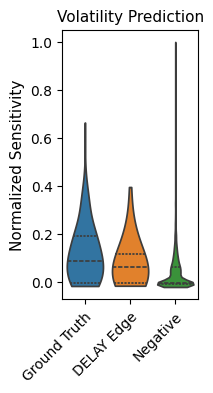

In [26]:
fig, ax = plt.subplots(1, 1, figsize = (1.75, 3.5))
data = [edges_ref.recall.values, edges_pred.recall.values, edges_ctrl.recall.values]
sns.violinplot(data, cut = 0, bw_adjust = 2, inner = 'quart', ax = ax)
labels = ['Ground Truth', 'DELAY Edge', 'Negative']
ax.set_xticklabels(labels, rotation = 45, rotation_mode = 'anchor', ha = 'right')
ax.set_ylabel('Normalized Sensitivity', size = 11)
ax.set_title('Volatility Prediction', size = 11)
plt.show()